# Imports

In [37]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [38]:
import matplotlib.pyplot as plt

In [39]:
import cv2

# Parameters

In [40]:
path_assets = PROJECT_DIR / 'assets'
path_imgs_atv = path_assets / "atv02_lista02-assets"

# Questão 10

## 1) Lendo

In [41]:
img_names = ["cameraman.png"]
imgs = {
    i.split(".")[0]: cv2.imread(path_imgs_atv / i, cv2.IMREAD_GRAYSCALE) for i in img_names
}

## 2) Parameters

In [42]:
# Sigmas para o filtro gaussiano
sigmas = [1, 2, 4]

# Parametros para o método de deteccao de canny
low = 50
high = 150

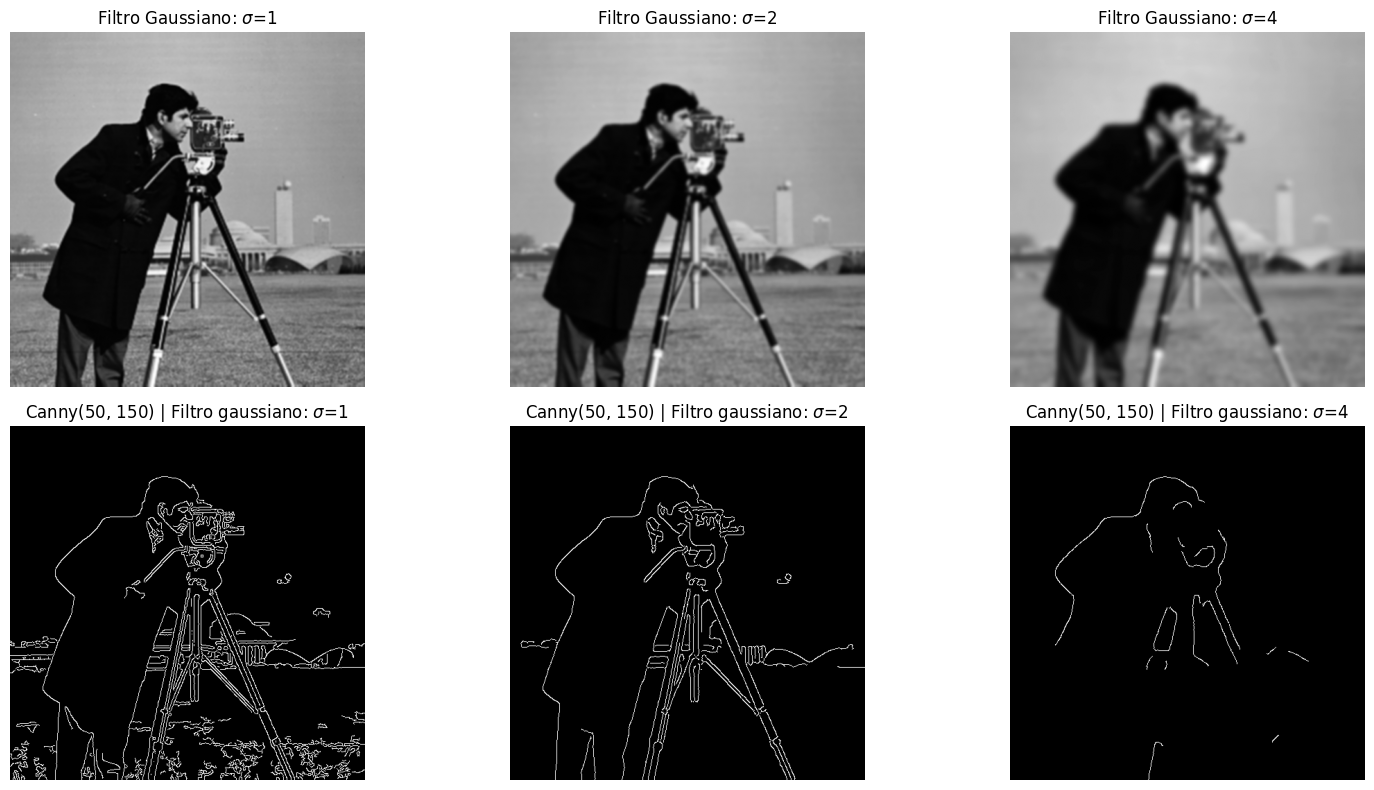

In [43]:
fig, ax = plt.subplots(2, len(sigmas), figsize=(16, 8))
ax = ax.reshape(2, len(sigmas))  # Organiza os subplots em 2 linhas

for i, sigma in enumerate(sigmas):
    # Aplica filtro Gaussiano com sigma definido
    blurred = cv2.GaussianBlur(
        imgs["cameraman"],
        (0, 0),
        sigmaX=sigma,
        sigmaY=sigma
    )

    # Exibe a imagem embaçada (linha 1)
    ax[0, i].imshow(blurred, cmap='gray')
    ax[0, i].set_title(rf'Filtro Gaussiano: $\sigma$={sigma}')
    ax[0, i].axis('off')

    # Detecta bordas com Canny
    edges = cv2.Canny(
        blurred,
        low,
        high
    )

    # Exibe os resultados do Canny (linha 2)
    ax[1, i].imshow(edges, cmap='gray')
    ax[1, i].set_title(f'Canny{low, high} | Filtro gaussiano:' + rf' $\sigma$={sigma}')
    ax[1, i].axis('off')

fig.tight_layout()
fig.savefig(path_assets / "atv02-q10-02.png", dpi=400, bbox_inches='tight')
plt.show()